<a href="https://colab.research.google.com/github/ROMAPRE/aeco-ppe-detection-yolov8/blob/main/notebooks/train_yolov8_ppe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train YOLOv8 Object Detection on a Custom Dataset

---

[![Roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/how-to-train-yolov8-on-a-custom-dataset)
[![YouTube](https://badges.aleen42.com/src/youtube.svg)](https://youtu.be/wuZtUMEiKWY)
[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/ultralytics/ultralytics)

Ultralytics YOLOv8 is a popular version of the YOLO (You Only Look Once) object detection and image segmentation model developed by Ultralytics. The YOLOv8 model is designed to be fast, accurate, and easy to use, making it an excellent choice for a wide range of object detection and image segmentation tasks. It can be trained on large datasets and is capable of running on a variety of hardware platforms, from CPUs to GPUs.

## Disclaimer

If you notice that our notebook behaves incorrectly - especially if you experience errors that prevent you from going through the tutorial - don't hesitate! Let us know and open an [issue](https://github.com/roboflow/notebooks/issues) on the Roboflow Notebooks repository.

## Accompanying Blog Post

We recommend that you follow along in this notebook while reading the accompanying [Blog Post](https://blog.roboflow.com/how-to-train-yolov8-on-a-custom-dataset/).

## Pro Tip: Use GPU Acceleration

If you are running this notebook in Google Colab, navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`. This will ensure your notebook uses a GPU, which will significantly speed up model training times.

## Steps in this Tutorial

In this tutorial, we are going to cover:

- Before you start
- Install YOLOv8
- CLI Basics
- Inference with Pre-trained COCO Model
- Roboflow Universe
- Preparing a custom dataset
- Custom Training
- Validate Custom Model
- Inference with Custom Model

**Let's begin!**

#1- Chequeo de la GPU
## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


#2-Instalación de YOLOv8

YOLOv8 can be installed in two ways - from the source and via pip. This is because it is the first iteration of YOLO to have an official package.

In [3]:
# Install YOLOv8
!pip install ultralytics -q

from IPython import display
display.clear_output()

# prevent ultralytics from tracking your activity
!yolo settings sync=False

import ultralytics
ultralytics.checks()

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 21.6/107.7 GB disk)


In [4]:
from ultralytics import YOLO

from IPython.display import display, Image

#3-API_KEY
##Descarga el dataset dede Roboflow


In [5]:
!pip install roboflow -q

from google.colab import userdata
from roboflow import Roboflow

api_key = userdata.get("ROBOFLOW_API_KEY")

if not api_key:
    raise ValueError("Debes configurar ROBOFLOW_API_KEY en Colab Secrets")

rf = Roboflow(api_key=api_key)

project = rf.workspace("rossanas-workspace-ltw8l").project("maic1125_m4t3")
version = project.version(4)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


#4- Entrenamiento YOLOv8 con dataset MAIC1125_M4T3-4
## Custom Training

In [6]:
%cd {HOME}

!yolo task=detect mode=train \
model=yolov8s.pt \
data={dataset.location}/data.yaml \
epochs=40 \
imgsz=640 \
batch=16 \
plots=True

/content
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/MAIC1125_M4T3-4/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

/content


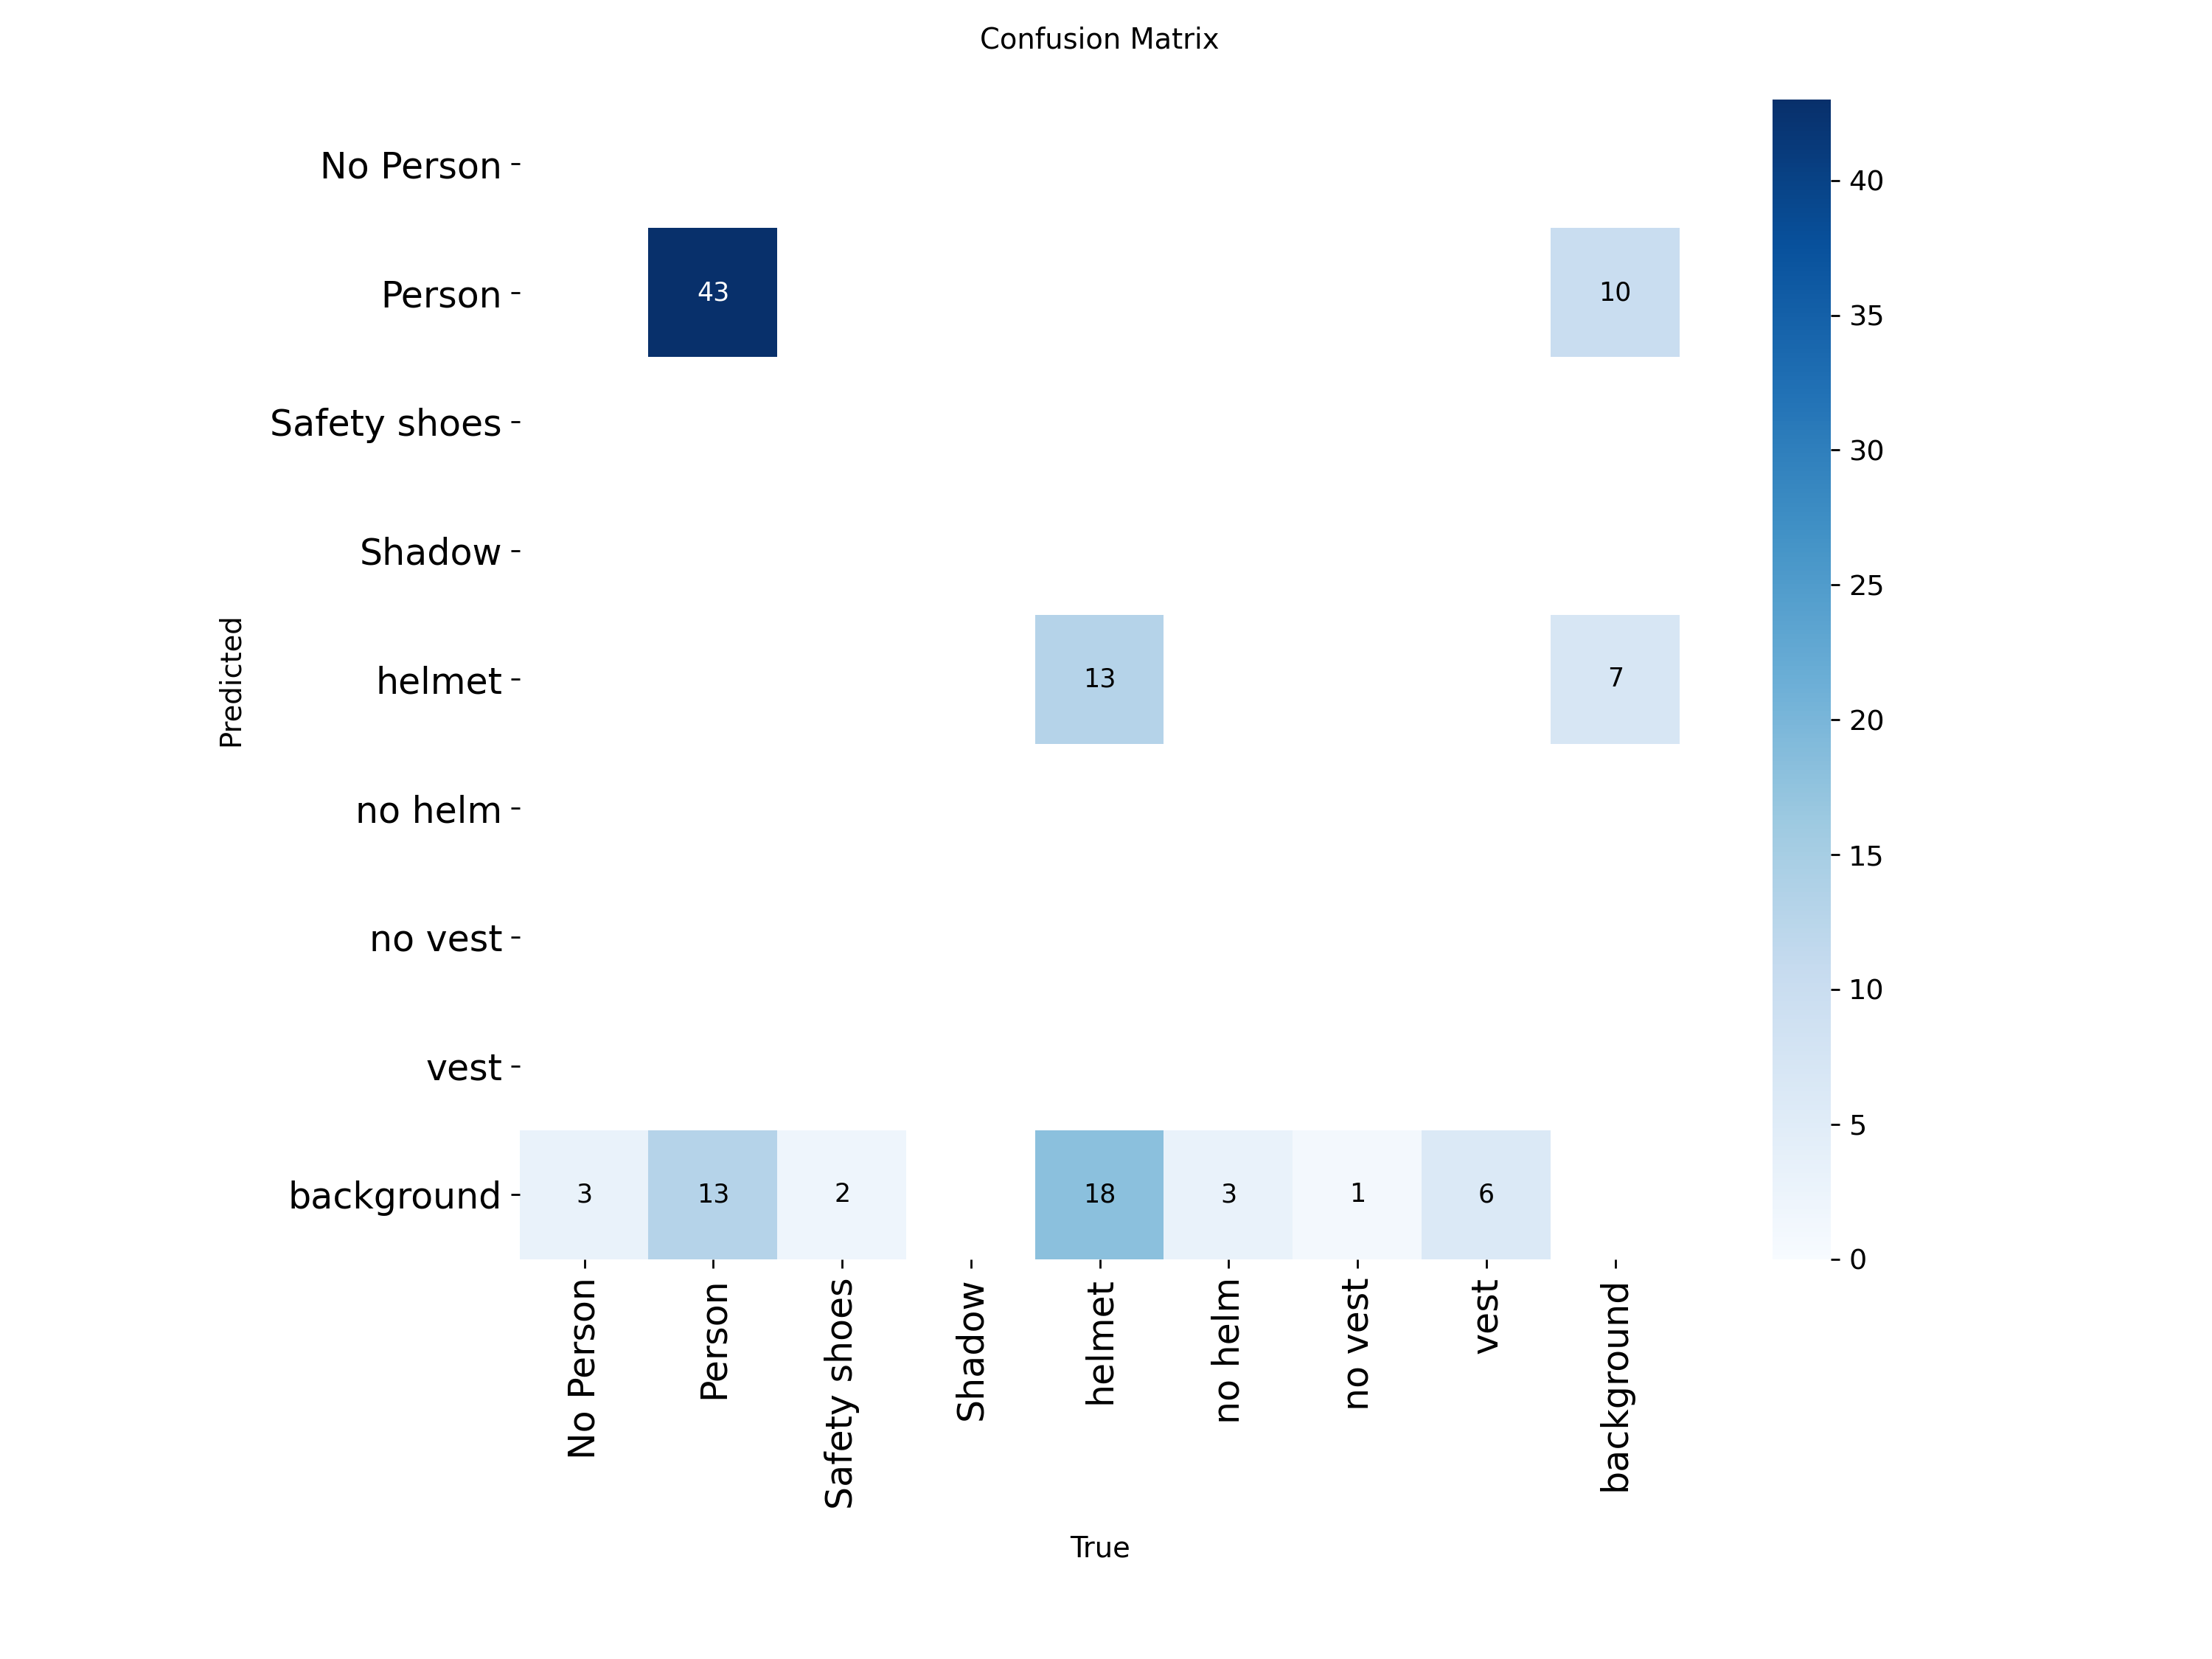

In [12]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

/content


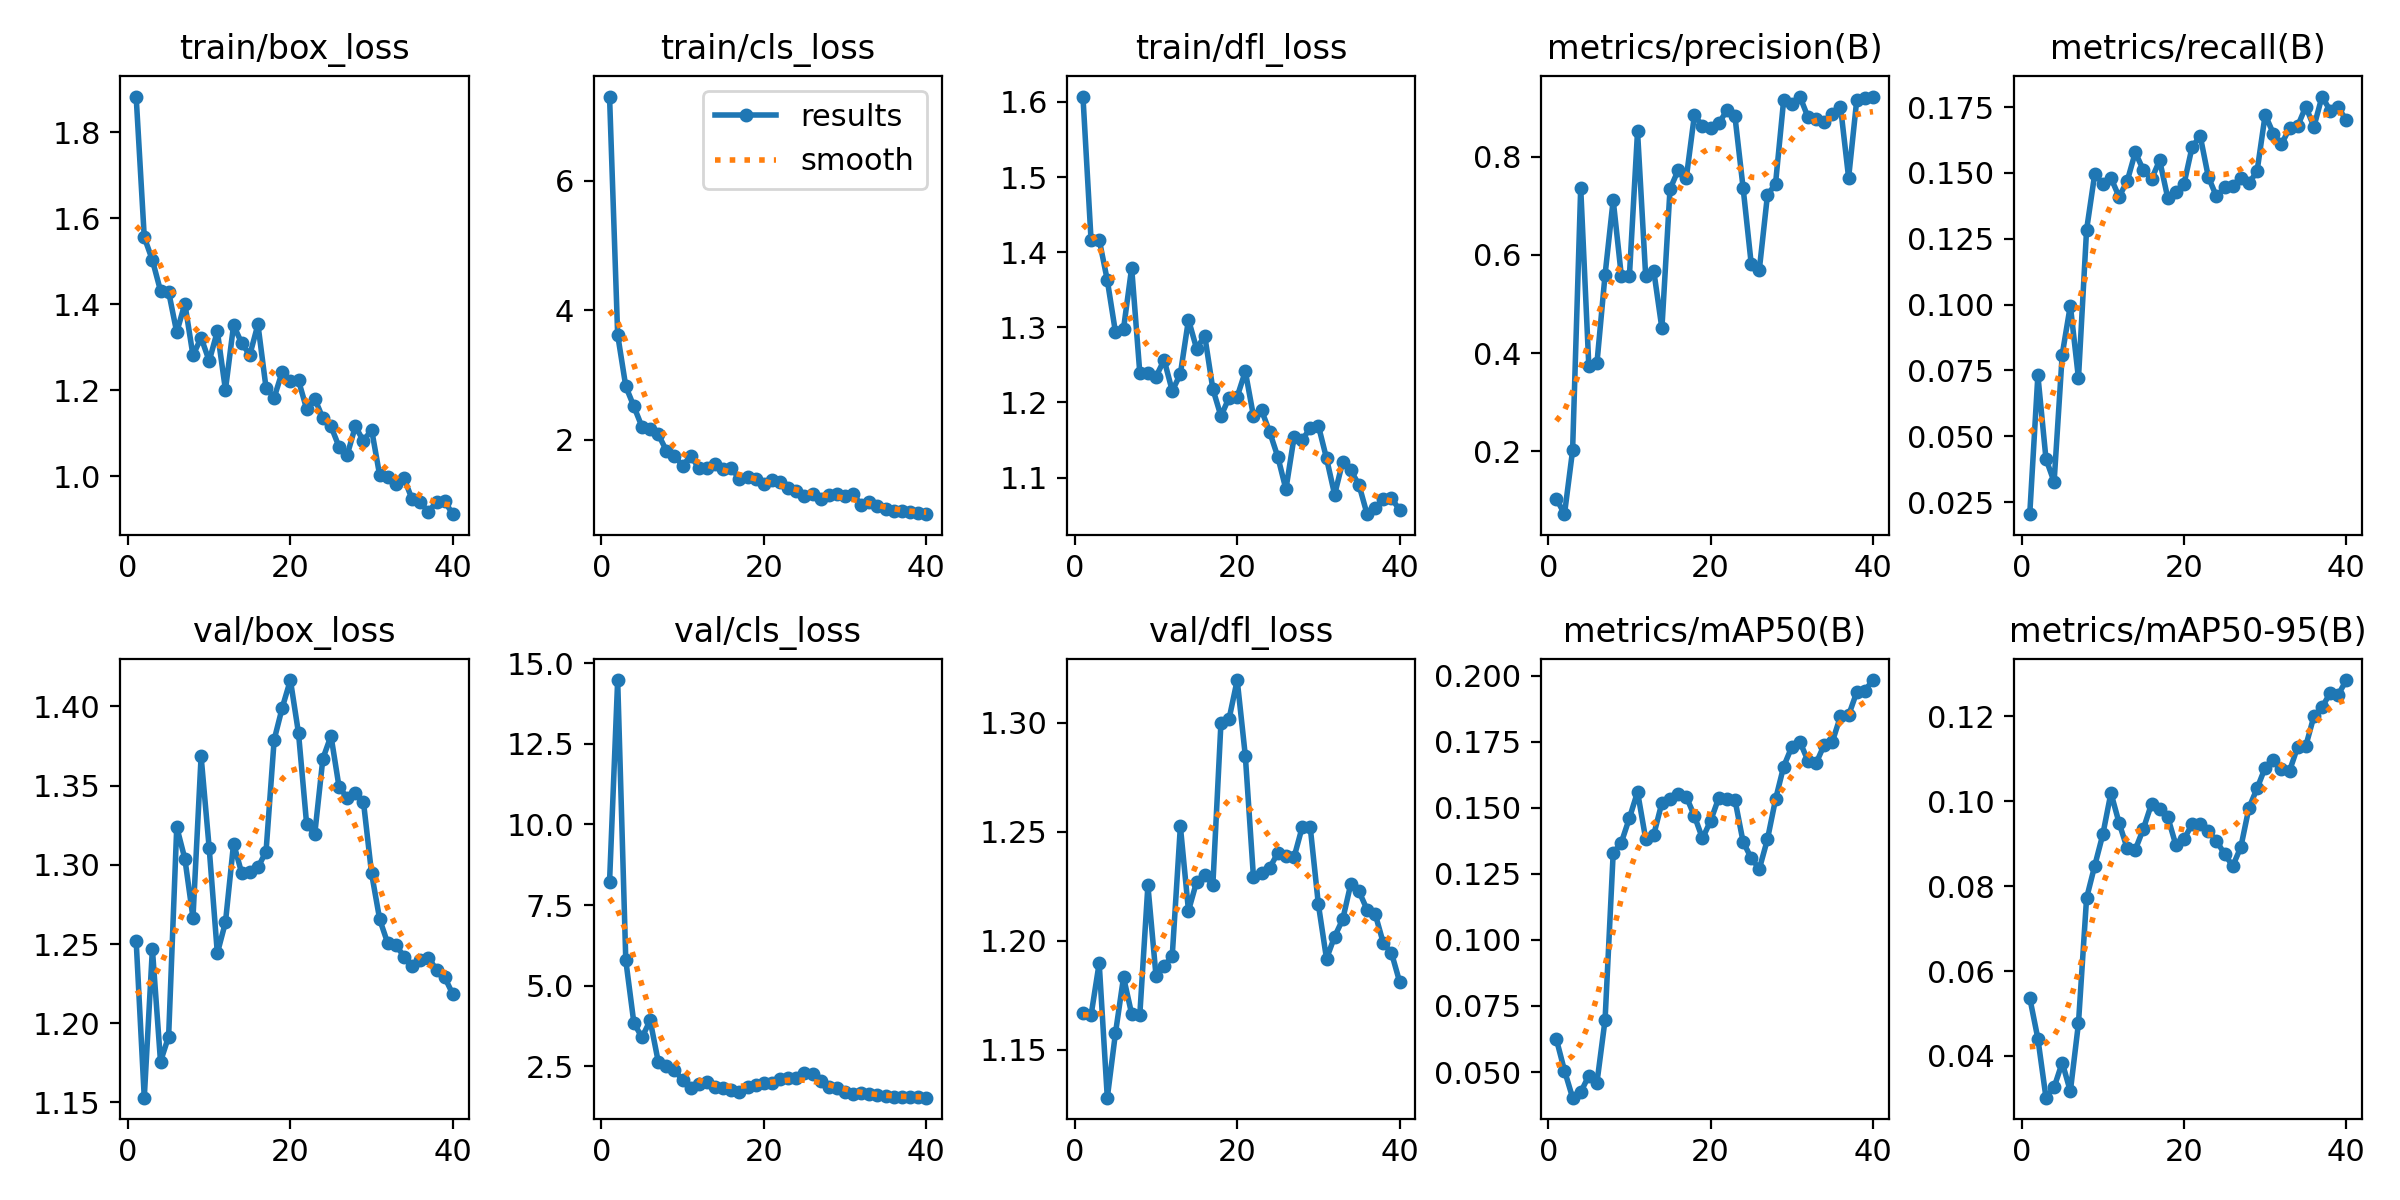

In [13]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/results.png', width=600)

/content


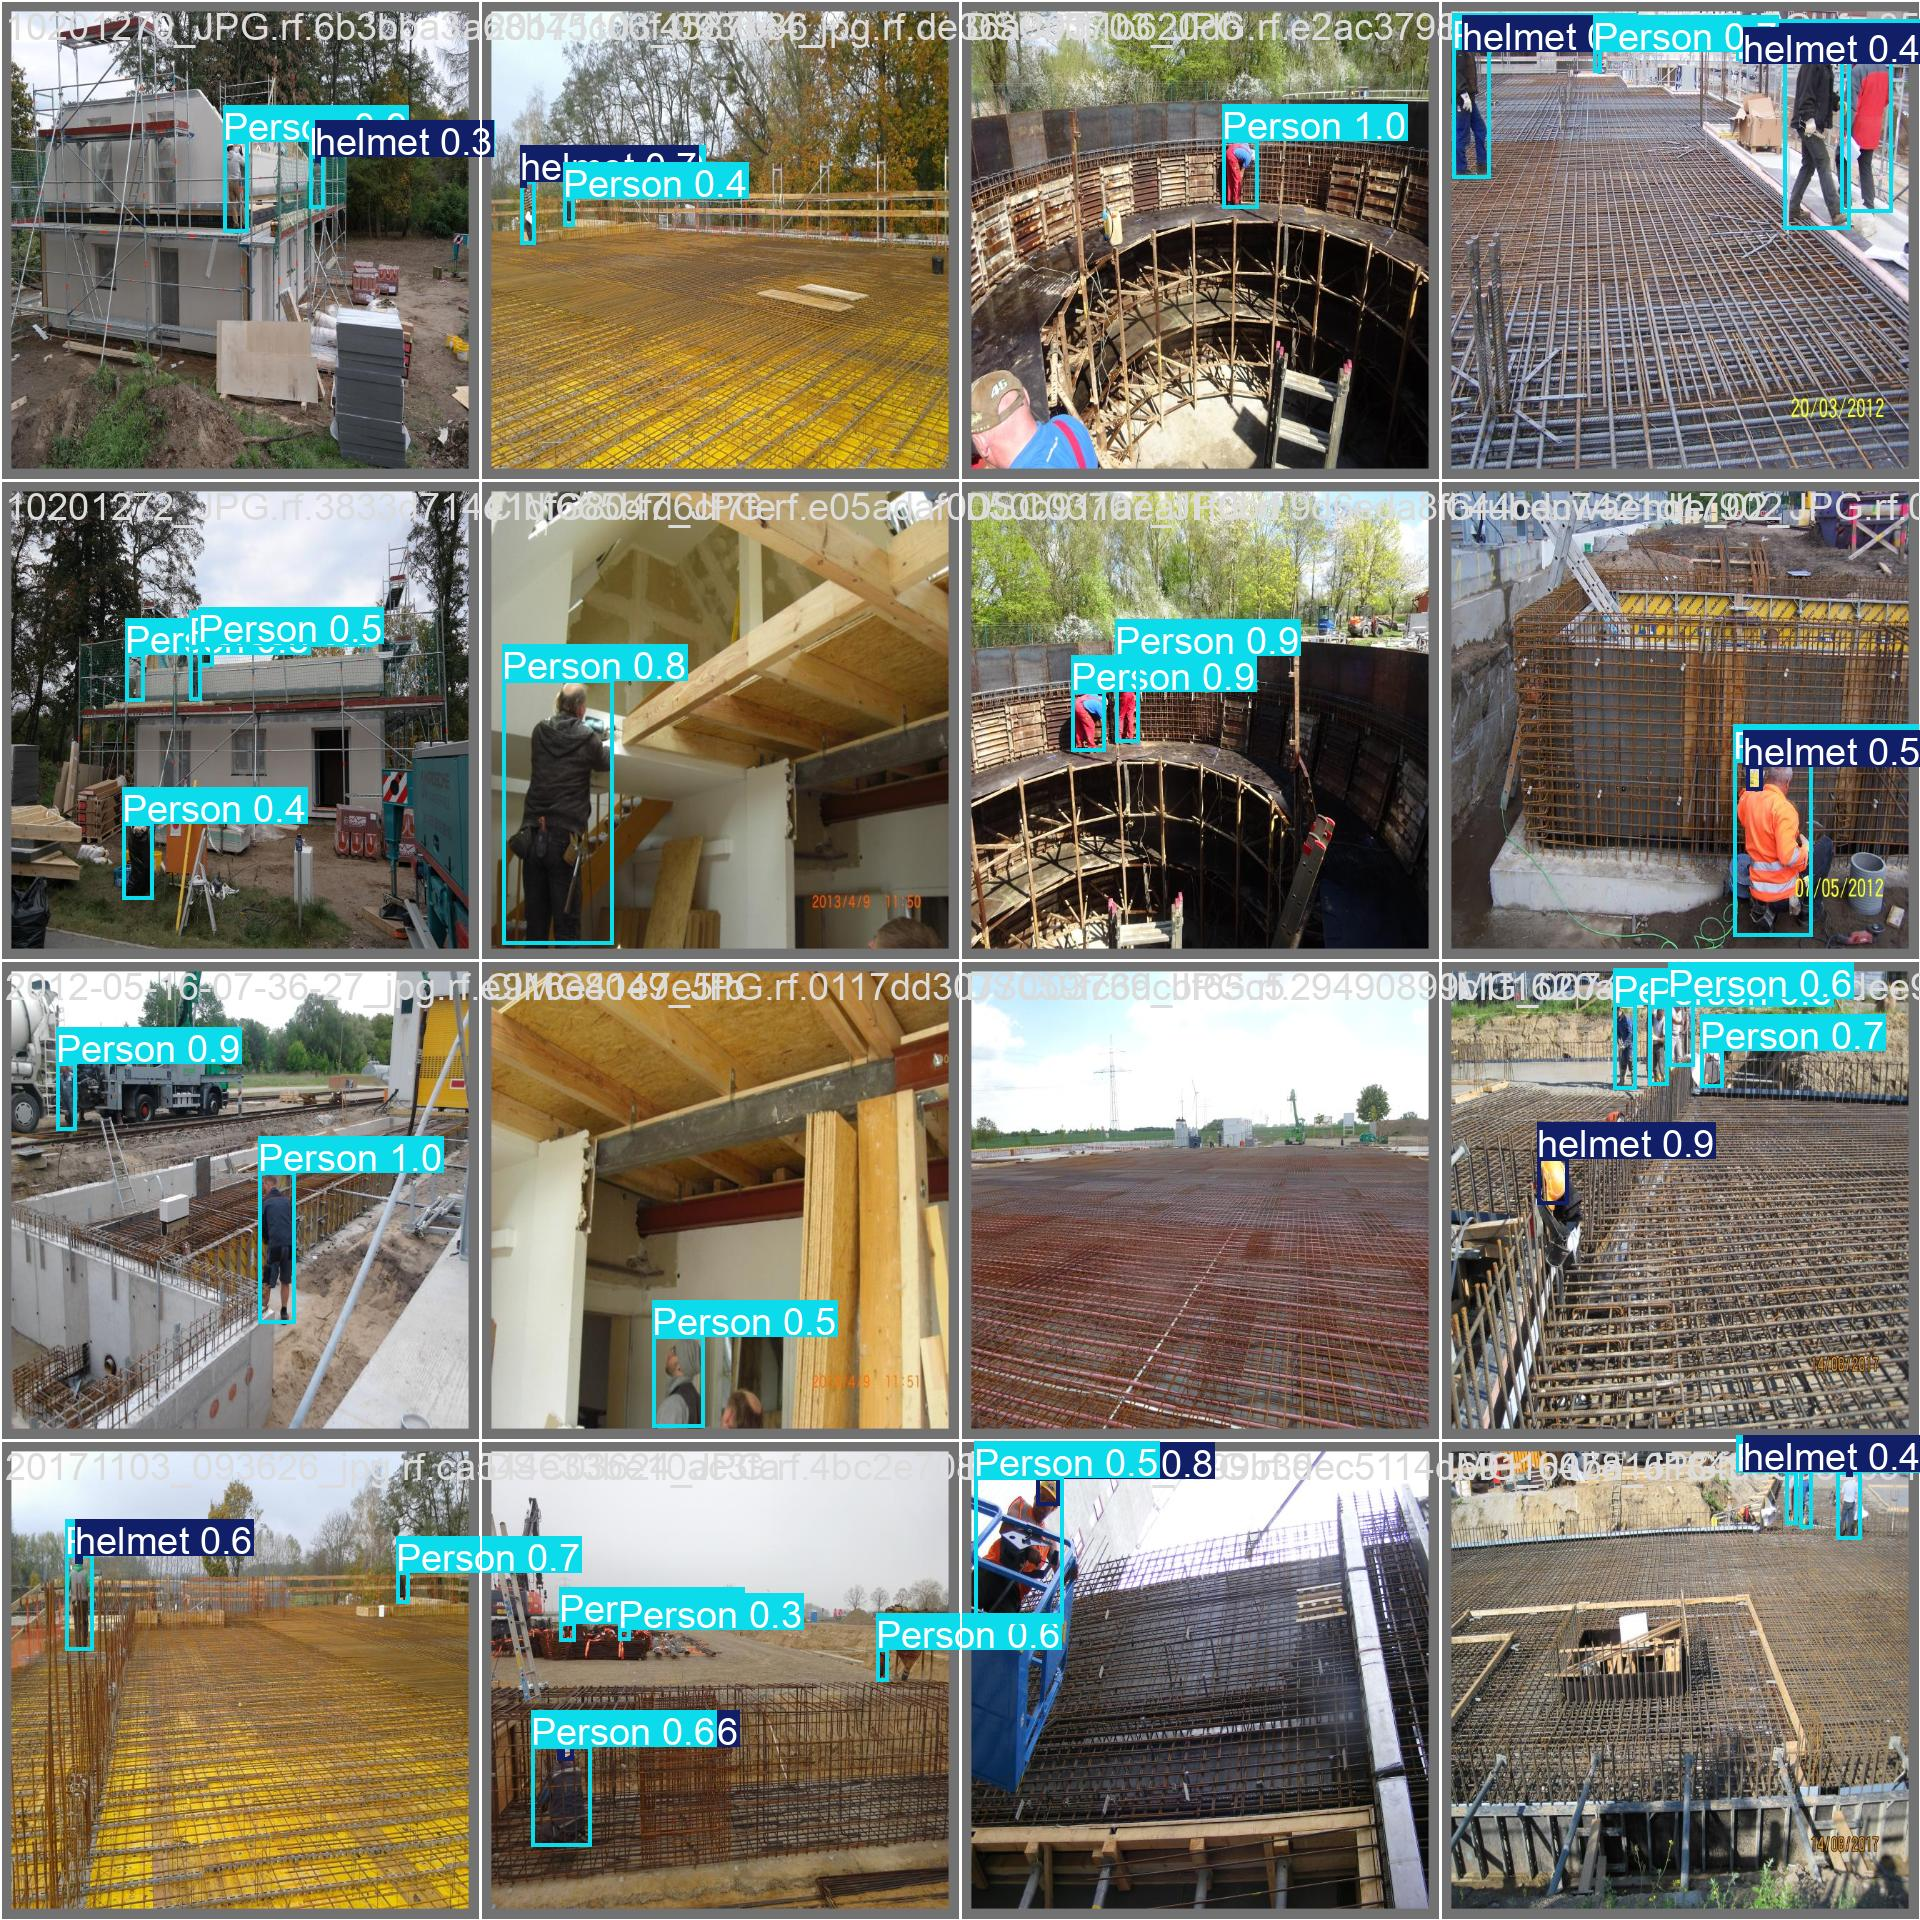

In [14]:
%cd {HOME}
Image(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

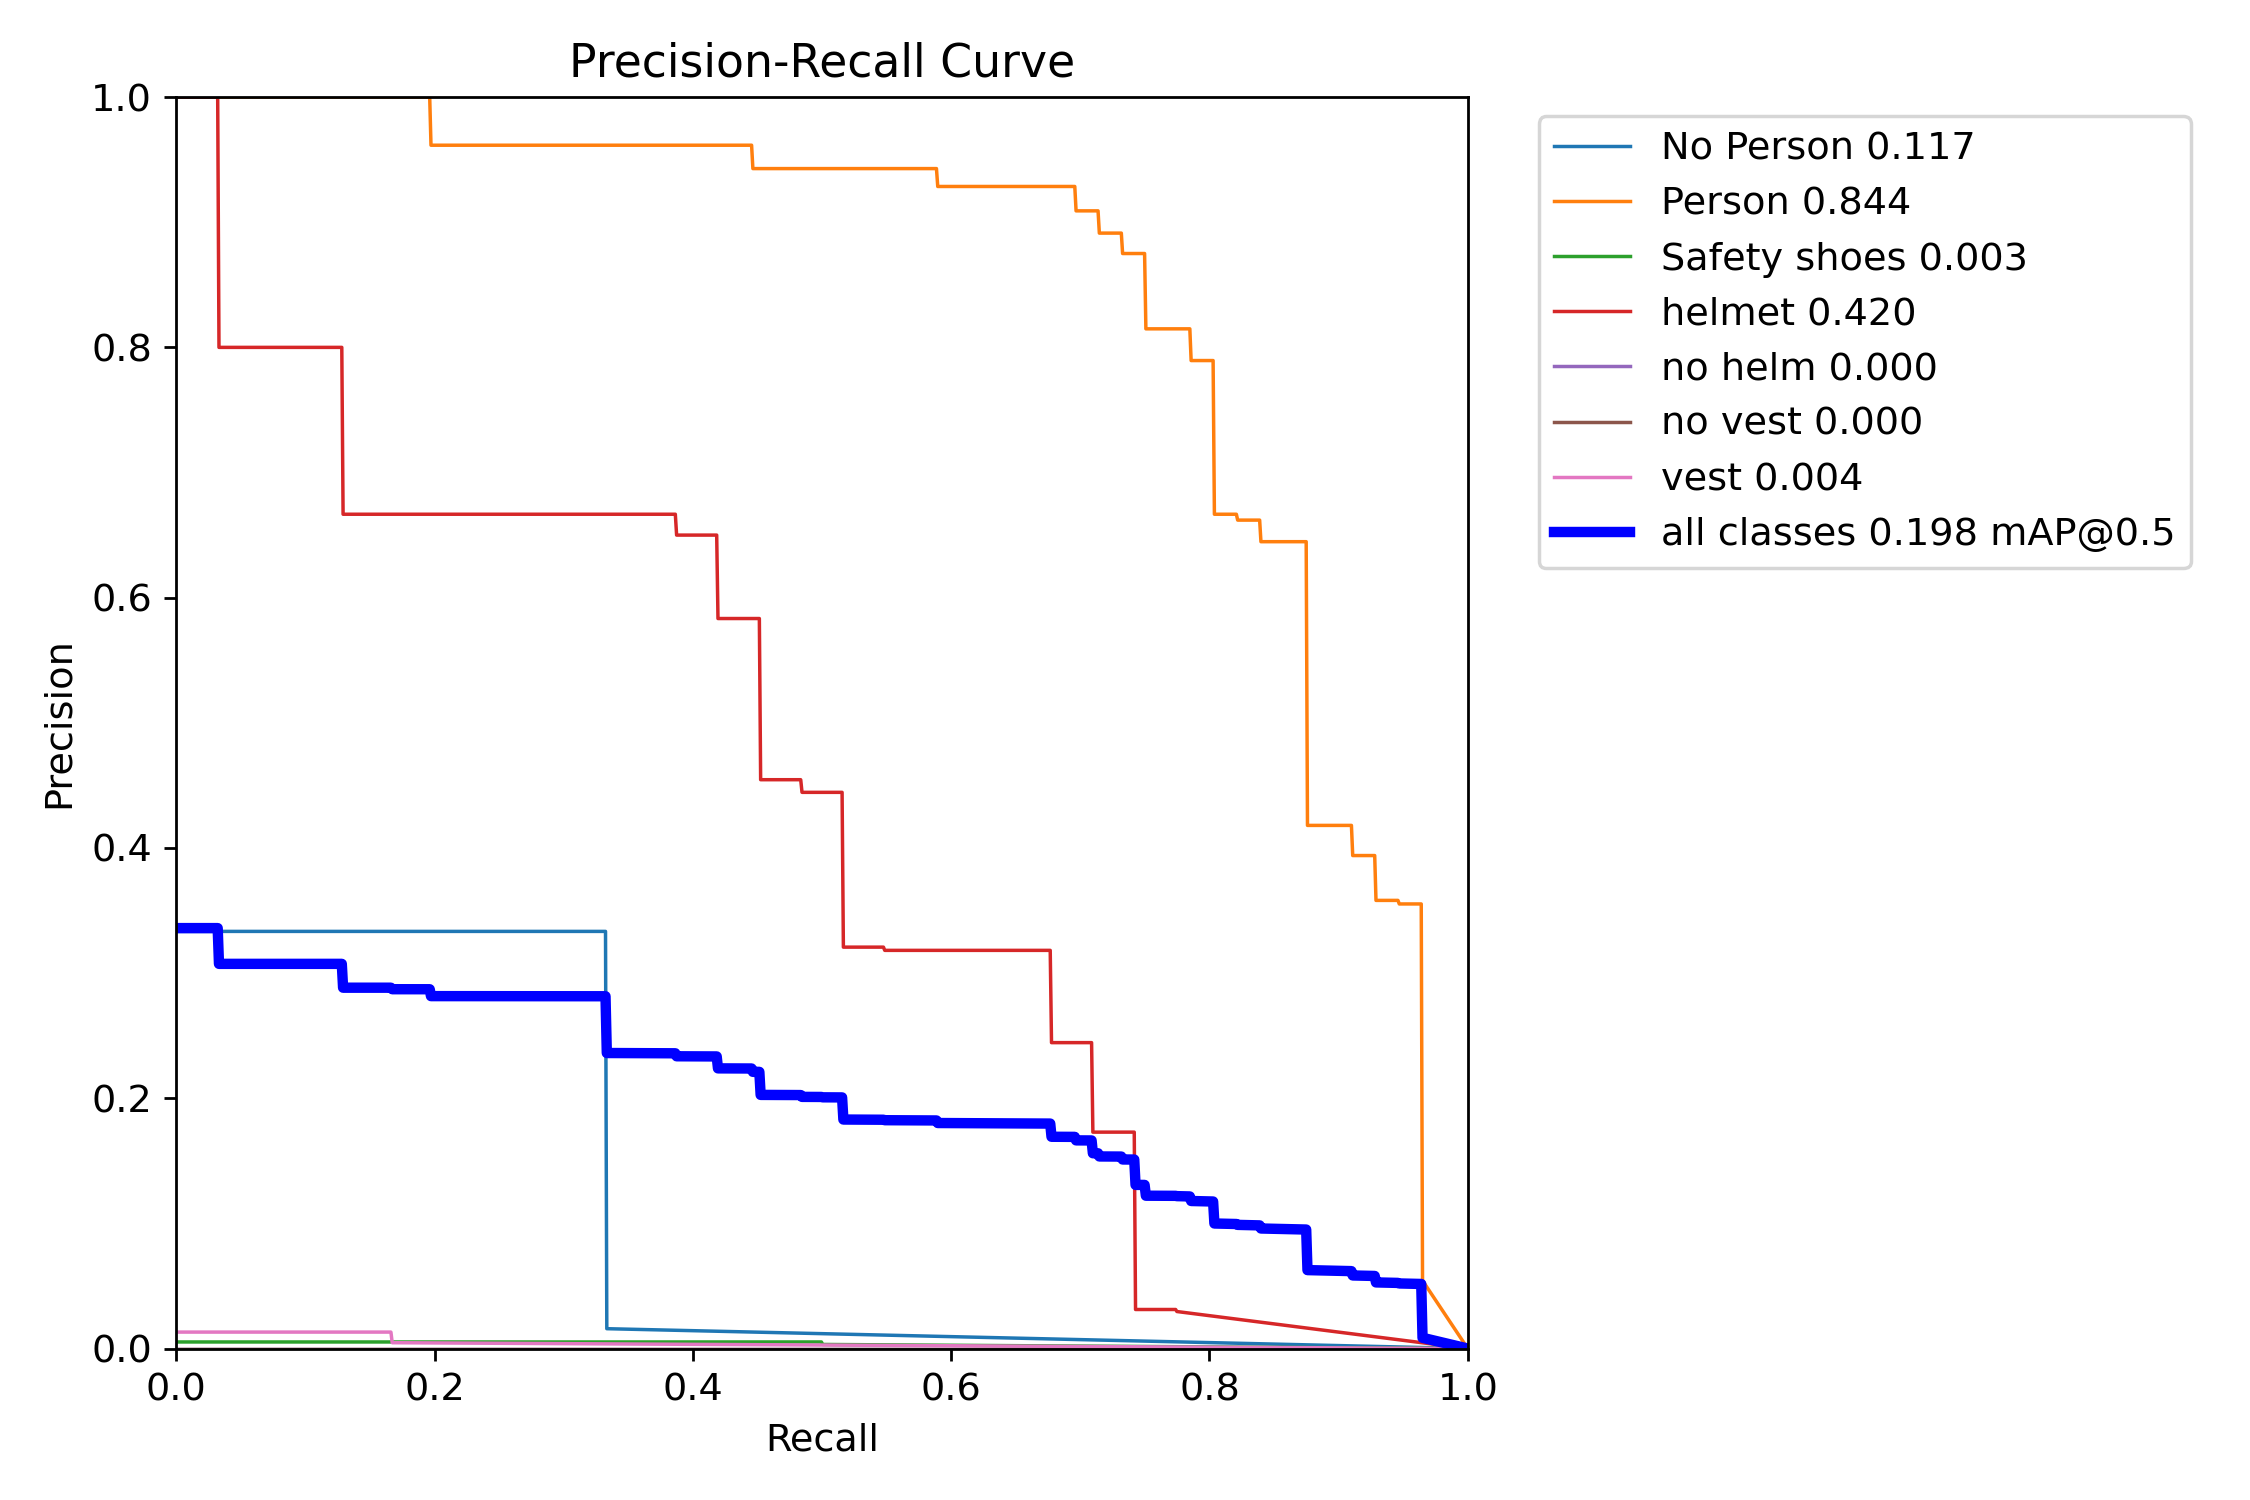

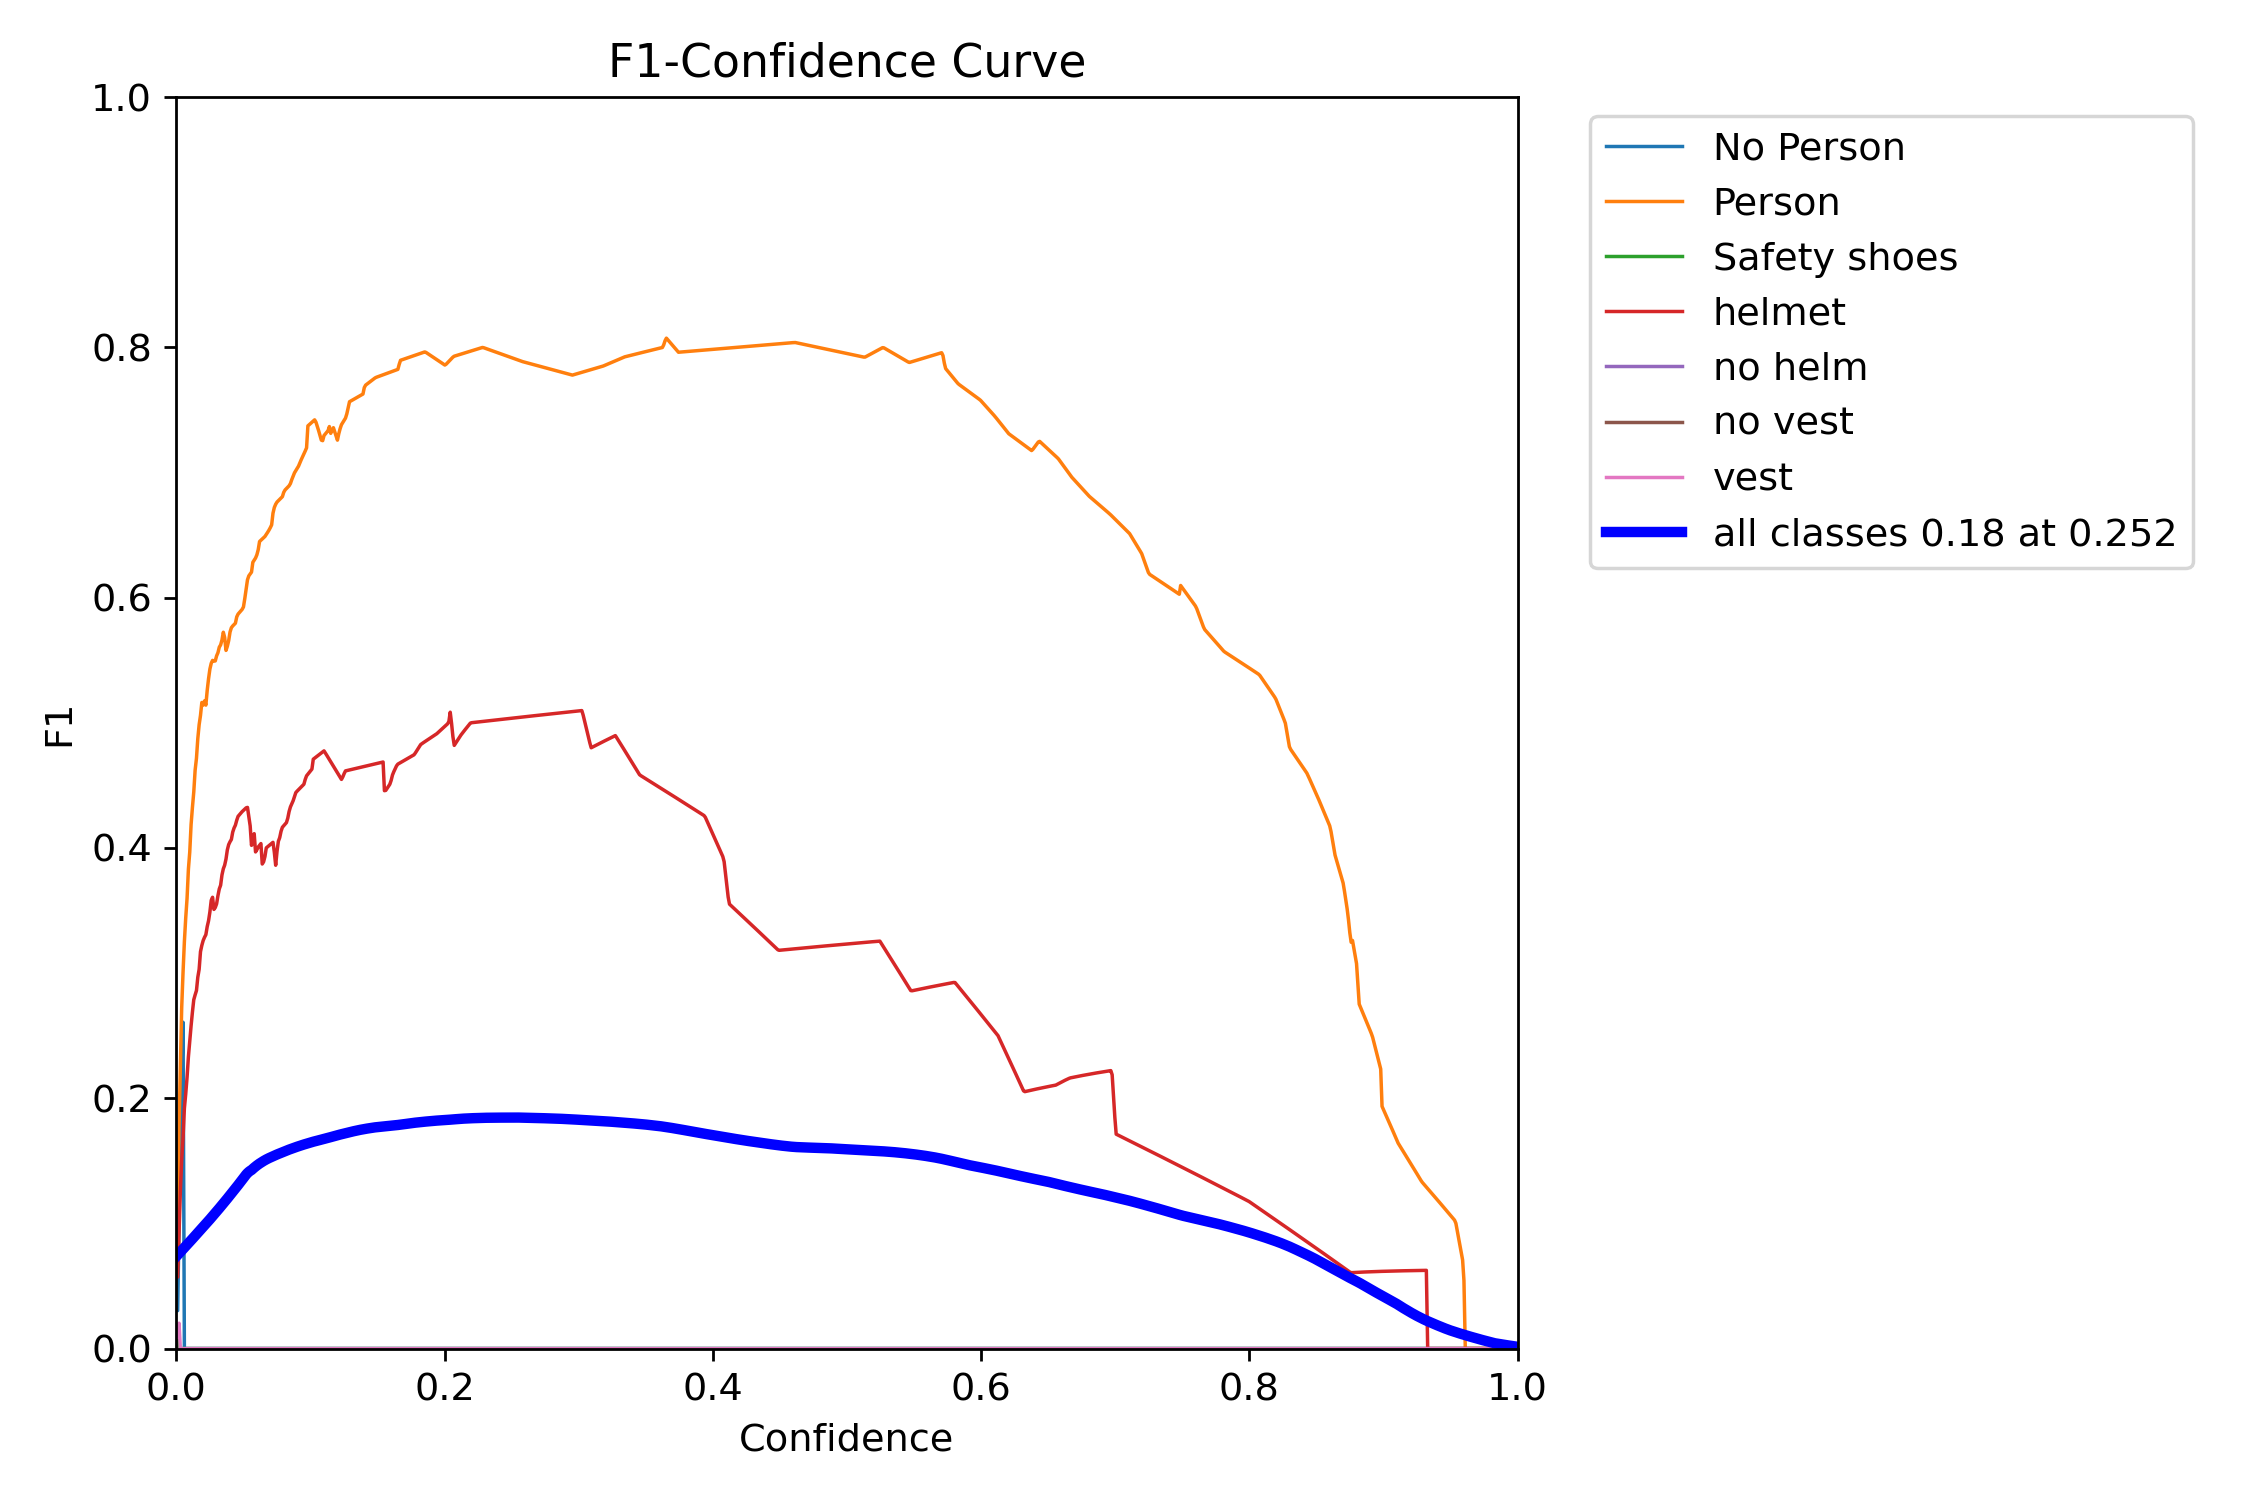

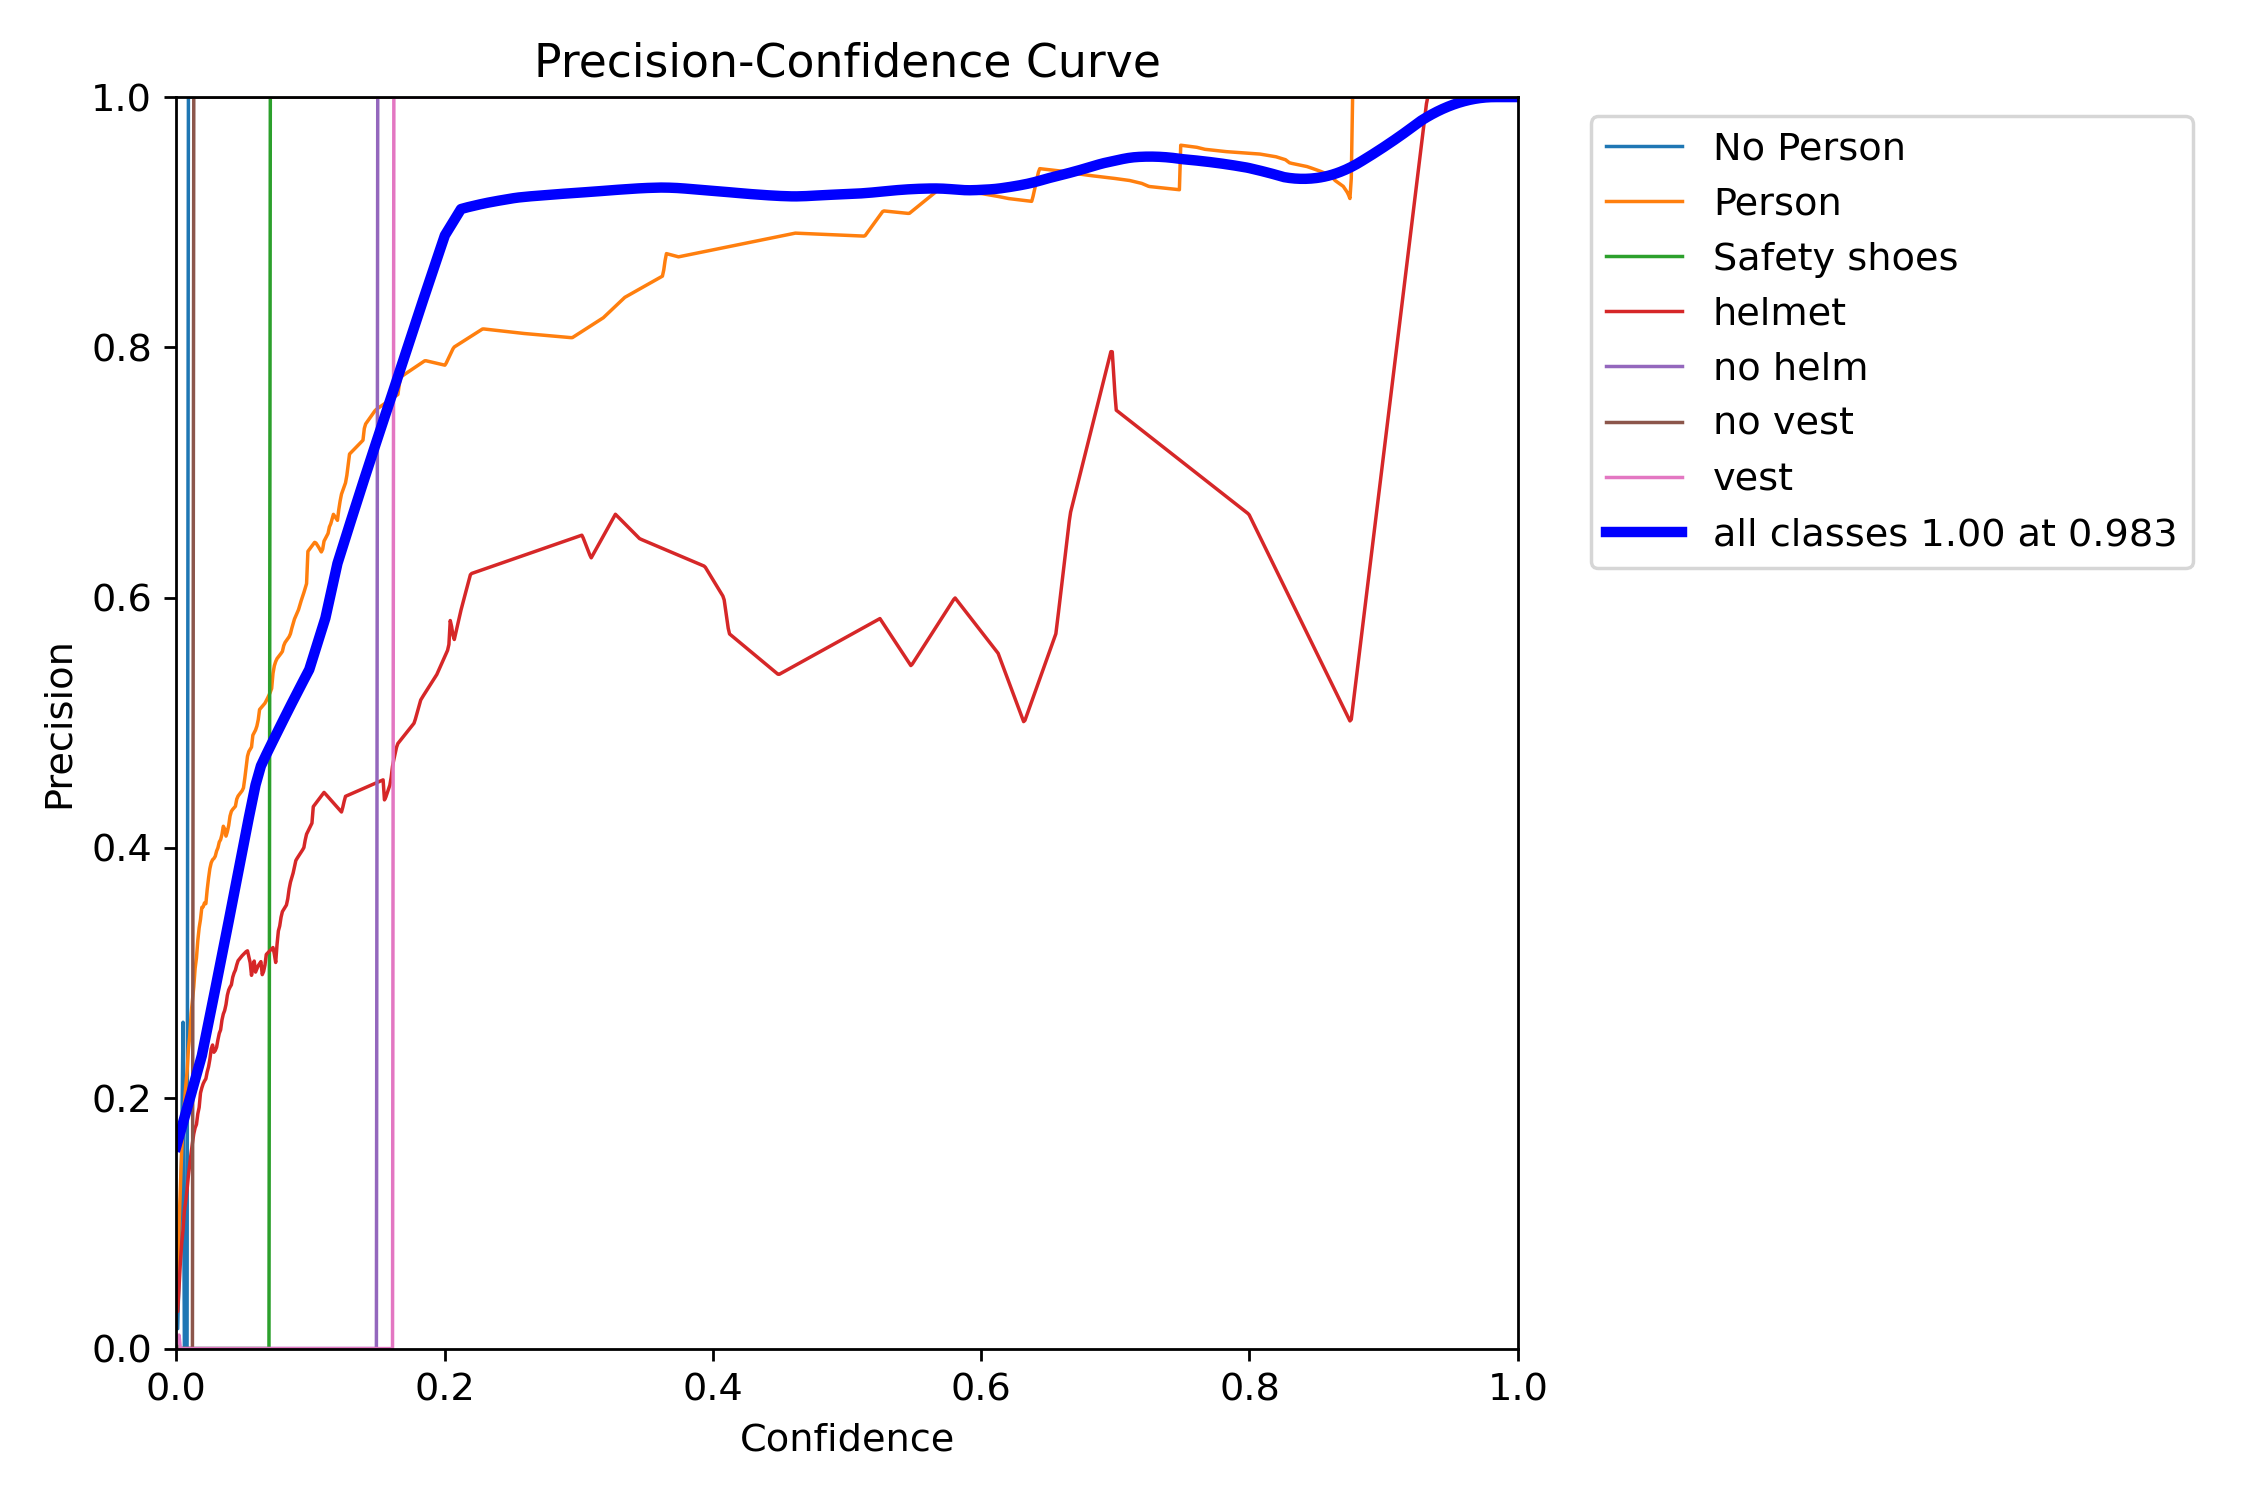

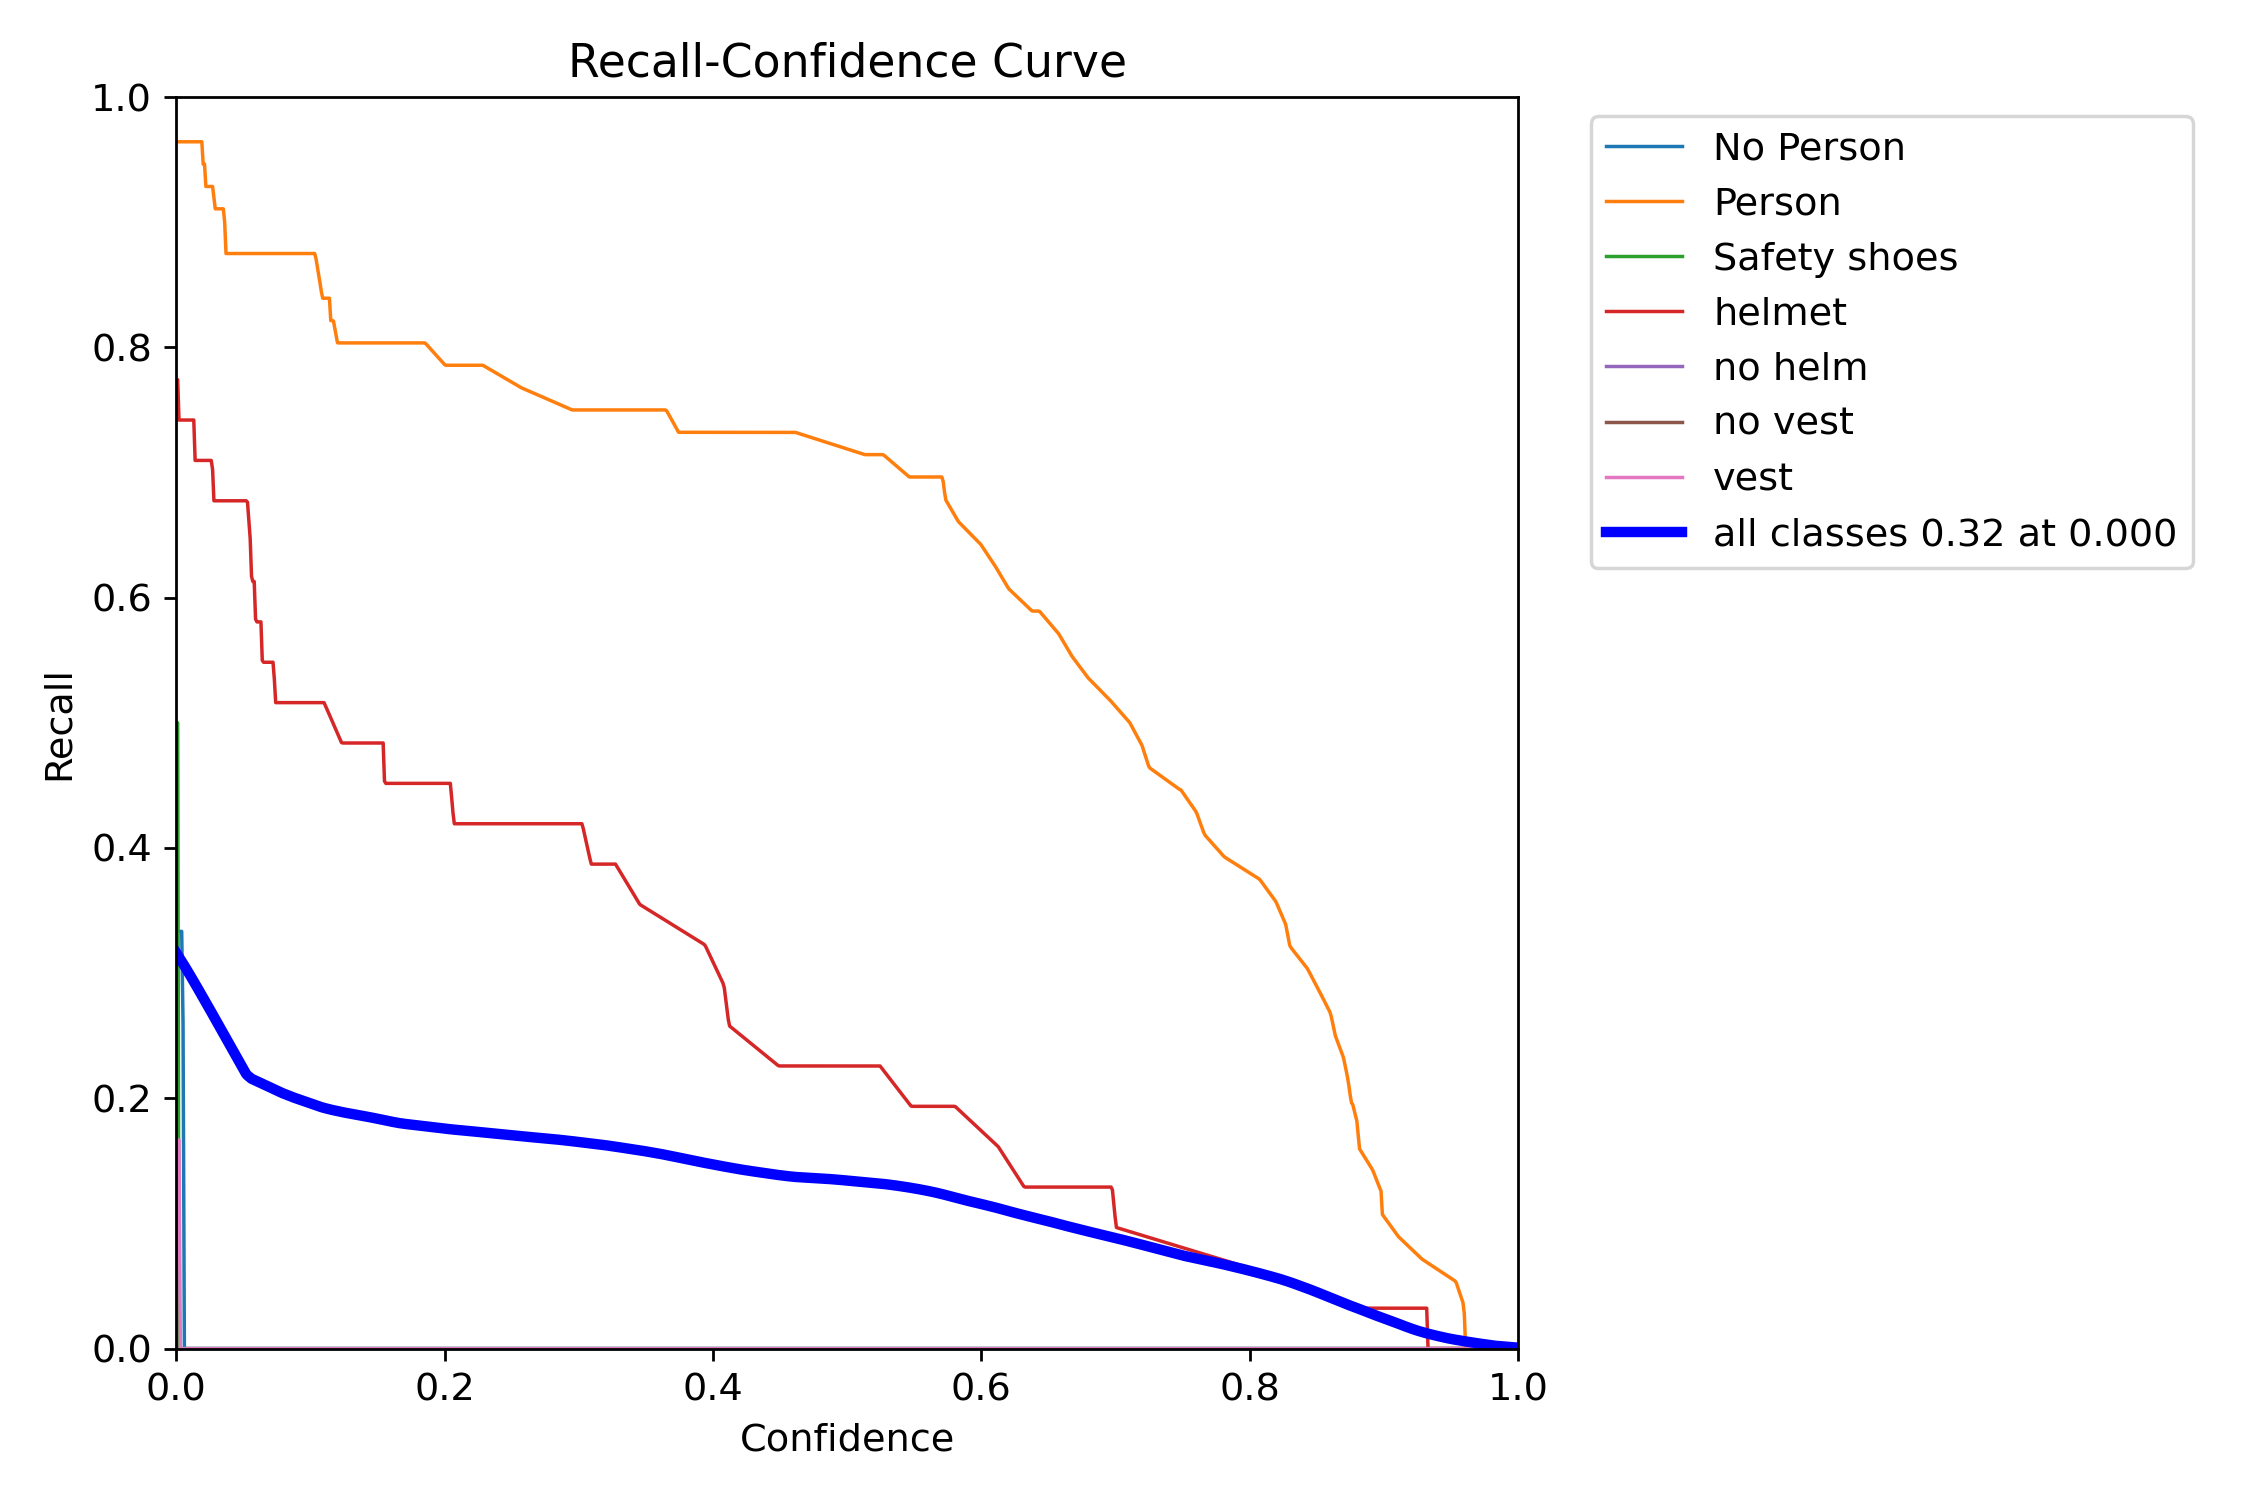

In [18]:
from IPython.display import Image, display

display(Image(filename=f'{HOME}/runs/detect/train/BoxPR_curve.png', width=600))
display(Image(filename=f'{HOME}/runs/detect/train/BoxF1_curve.png', width=600))
display(Image(filename=f'{HOME}/runs/detect/train/BoxP_curve.png', width=600))
display(Image(filename=f'{HOME}/runs/detect/train/BoxR_curve.png', width=600))

#5- Validar modelo
## Validate Custom Model

In [19]:
%cd {HOME}

!yolo task=detect mode=val \
model={HOME}/runs/detect/train/weights/best.pt \
data={dataset.location}/data.yaml \
imgsz=640 \
plots=True

/content
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 11,128,680 parameters, 0 gradients, 28.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 540.2±102.3 MB/s, size: 104.1 KB)
val: Scanning /content/MAIC1125_M4T3-4/valid/labels.cache... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 1.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 9.4s/it 18.9s
                   all         20        102       0.92       0.17      0.198      0.129
             No Person          3          3          1          0      0.117     0.0702
                Person         20         56      0.812      0.771      0.844      0.609
          Safety shoes          1          2          1          0    0.00344   0.000344
                helmet         11         31      0.631      0.419       0.42       0.22
               no helm          2 

#6- Ejecutar inferencia
## Inference with Custom Model

In [20]:
%cd {HOME}

!yolo task=detect mode=predict \
model={HOME}/runs/detect/train/weights/best.pt \
conf=0.25 \
imgsz=640 \
source={dataset.location}/test/images \
save=True

/content
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 11,128,680 parameters, 0 gradients, 28.5 GFLOPs

image 1/10 /content/MAIC1125_M4T3-4/test/images/10201267_JPG.rf.58783b0836ef504712ce9b8fa28f6de7.jpg: 640x640 3 Persons, 677.9ms
image 2/10 /content/MAIC1125_M4T3-4/test/images/10201269_JPG.rf.5207088889db4618ad2bc5752428e04f.jpg: 640x640 1 Person, 1 helmet, 618.9ms
image 3/10 /content/MAIC1125_M4T3-4/test/images/Bopl_Nr8_01_JPG.rf.d52a4cb226bd93886d8928bbc32c72c3.jpg: 640x640 (no detections), 621.1ms
image 4/10 /content/MAIC1125_M4T3-4/test/images/Dachstuhl_JPG.rf.01be793982ce38264b64848e90c89143.jpg: 640x640 1 helmet, 614.2ms
image 5/10 /content/MAIC1125_M4T3-4/test/images/IMG_0330_JPG.rf.243a75deb6b0c3bdfe29f458b0a09ef3.jpg: 640x640 2 Persons, 1 Safety shoes, 1 helmet, 618.7ms
image 6/10 /content/MAIC1125_M4T3-4/test/images/IMG_1267_JPG.rf.3c12480324b851eafb8a275a29f25716.jpg: 640x640 5 Persons, 2 helmets, 622

**NOTE:** Let's take a look at few results.

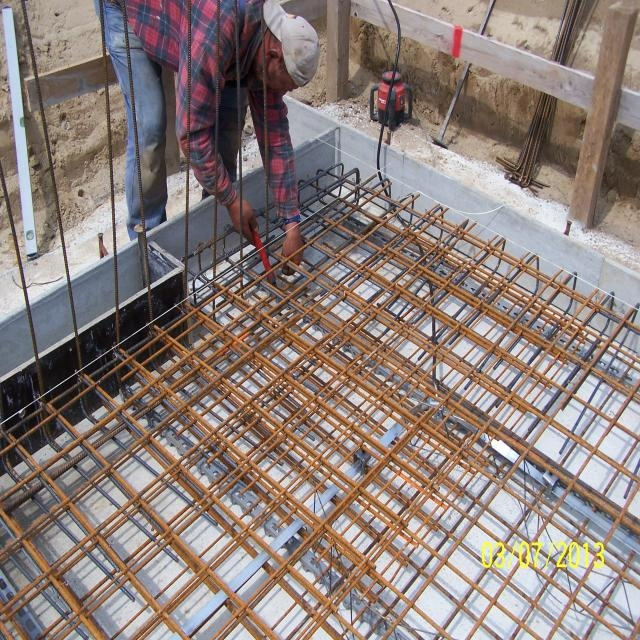

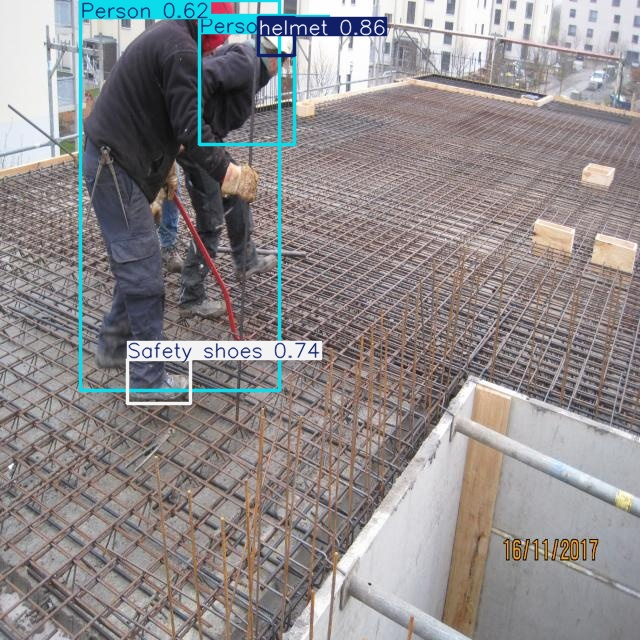

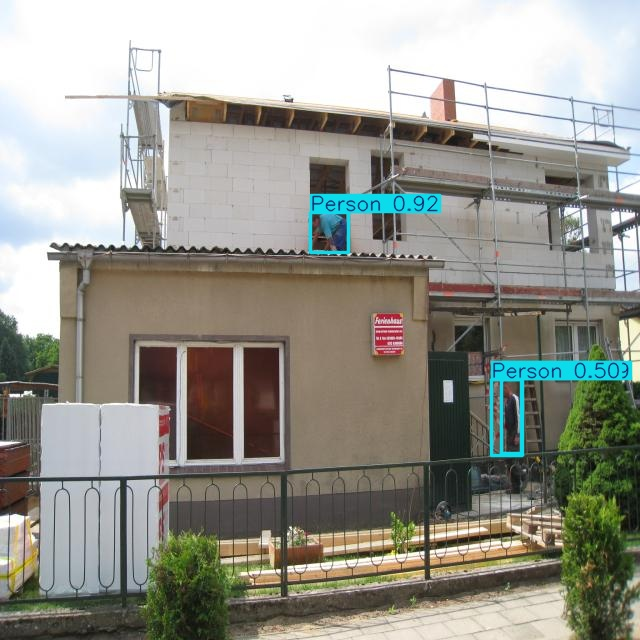

In [21]:
import glob
from IPython.display import Image, display

# Define the base path where the folders are located
base_path = f'{HOME}/runs/detect/'

# List all directories that start with 'predict' in the base path
subfolders = [os.path.join(base_path, d) for d in os.listdir(base_path)
              if os.path.isdir(os.path.join(base_path, d)) and d.startswith('predict')]

# Find the latest folder by modification time
latest_folder = max(subfolders, key=os.path.getmtime)

image_paths = glob.glob(f'{latest_folder}/*.jpg')[:3]

# Display each image
for image_path in image_paths:
    display(Image(filename=image_path, width=600))
    print("\n")

##7- Modelo entrenado en .zip

In [24]:
!zip -r modelo_entrenado.zip runs/detect/train

updating: runs/detect/train/ (stored 0%)
updating: runs/detect/train/train_batch2.jpg (deflated 1%)
updating: runs/detect/train/args.yaml (deflated 52%)
updating: runs/detect/train/BoxPR_curve.png (deflated 17%)
updating: runs/detect/train/labels.jpg (deflated 25%)
updating: runs/detect/train/BoxF1_curve.png (deflated 12%)
updating: runs/detect/train/train_batch0.jpg (deflated 1%)
updating: runs/detect/train/train_batch182.jpg (deflated 6%)
updating: runs/detect/train/BoxR_curve.png (deflated 14%)
updating: runs/detect/train/confusion_matrix.png (deflated 25%)
updating: runs/detect/train/weights/ (stored 0%)
updating: runs/detect/train/weights/last.pt (deflated 8%)
updating: runs/detect/train/weights/best.pt (deflated 8%)
updating: runs/detect/train/val_batch0_labels.jpg (deflated 4%)
updating: runs/detect/train/train_batch1.jpg (deflated 1%)
updating: runs/detect/train/results.png (deflated 7%)
updating: runs/detect/train/train_batch180.jpg (deflated 5%)
updating: runs/detect/train/tr